# 📊 K-Nearest Neighbors (KNN) — From Zero to Hero
### Beginner-Friendly Guide with Kernel Tricks

Welcome! Today we'll master **KNN**, one of the simplest yet powerful machine learning algorithms.

**What we'll cover:**
1. Intuition & Core Concept
2. How KNN works (step-by-step)
3. Implementation from scratch
4. Using scikit-learn
5. Distance metrics & Kernel tricks
6. Hyperparameter tuning (K value)
7. Real-world examples

Let's go! 🚀


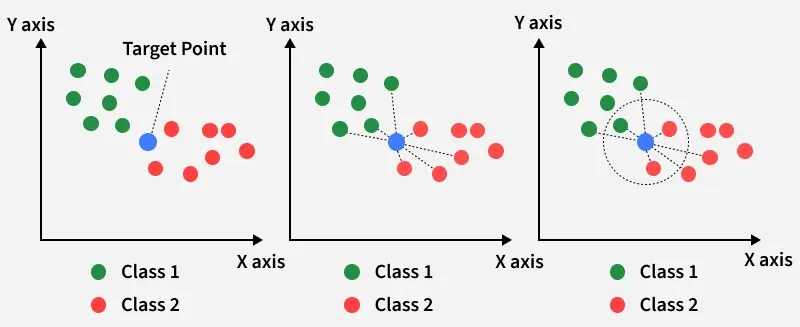

---
## 🛠️ Setup: Import Libraries

Let's start with the libraries we'll need.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 1️⃣ What is KNN? (Intuition)

**KNN = K-Nearest Neighbors**

The core idea is **incredibly simple**:

> To predict what something is, look at the K closest things around it and ask "what are they?"

Think of it like this:

```
YOU WANT TO PREDICT A NEW POINT

Your new point: ???
                   
Neighbors (K=3):
   ✅ Class A
   ✅ Class A  
   ✅ Class B

Majority vote: Class A wins! (2 out of 3)
```

### Real-world analogy:
If you're new to a city and want to know if a restaurant is good:
- Look at the **3 nearest restaurants** to it
- If 2 are good, this one is probably good too!
- If 2 are bad, this one is probably bad

### Why it's powerful:
✅ Simple and intuitive
✅ No training phase (lazy learner)
✅ Works for classification AND regression
✅ No assumptions about data distribution

### Why it's slow:
❌ Must calculate distance to every point
❌ Needs lot of memory
❌ Sensitive to irrelevant features


---
## 2️⃣ How KNN Works (Step by Step)

### The Algorithm:

```
TRAINING PHASE:
1. Load training data
2. Do nothing (lazy learner!)

PREDICTION PHASE:
1. For each new point you want to predict:
   a) Calculate distance to ALL training points
   b) Find the K closest points (neighbors)
   c) For CLASSIFICATION: take majority vote
   d) For REGRESSION: take average value
```

### Example with K=3:

```
Training data:
  Point 1: (1, 1) → Class A
  Point 2: (1.5, 1.2) → Class A
  Point 3: (8, 8) → Class B
  Point 4: (8.5, 8.2) → Class B
  Point 5: (9, 9) → Class B

NEW POINT: (1.2, 1.3) → ? (what class?)

Step 1: Calculate distances
  Distance to Point 1: 0.22
  Distance to Point 2: 0.07 ← closest
  Distance to Point 3: 9.85
  Distance to Point 4: 10.21
  Distance to Point 5: 11.00

Step 2: Take K=3 closest
  🏆 Point 2: 0.07 (Class A)
  🥈 Point 1: 0.22 (Class A)
  🥉 Point 3: 9.85 (Class B)

Step 3: Vote
  Class A: 2 votes
  Class B: 1 vote
  → PREDICTION: Class A ✅
```


---
## 3️⃣ Distance Metrics: How to Measure "Closeness"

The **distance metric** is critical. Here are the most common:

### 3.1 Euclidean Distance (L2 norm)
Most common. Straight-line distance in 2D/3D space.

```
Distance = sqrt((x1-x2)² + (y1-y2)²)
```

For 3D: `sqrt((x1-x2)² + (y1-y2)² + (z1-z2)²)`


In [2]:
import numpy as np

# Two points
p1 = np.array([0, 0])
p2 = np.array([3, 4])

# Euclidean distance
euclidean = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
print(f"Euclidean distance: {euclidean}")

# Using numpy
euclidean_np = np.linalg.norm(p1 - p2)
print(f"Euclidean (numpy): {euclidean_np}")

Euclidean distance: 5.0
Euclidean (numpy): 5.0


### 3.2 Manhattan Distance (L1 norm)
Distance if you can only move horizontally/vertically (like city blocks).

```
Distance = |x1-x2| + |y1-y2|
```


In [3]:
p1 = np.array([0, 0])
p2 = np.array([3, 4])

# Manhattan distance
manhattan = np.abs(p1[0]-p2[0]) + np.abs(p1[1]-p2[1])
print(f"Manhattan distance: {manhattan}")

# Using numpy
manhattan_np = np.linalg.norm(p1 - p2, ord=1)
print(f"Manhattan (numpy): {manhattan_np}")

Manhattan distance: 7
Manhattan (numpy): 7.0


### 3.3 Chebyshev Distance (L∞ norm)
Maximum absolute difference in any dimension.

```
Distance = max(|x1-x2|, |y1-y2|)
```


In [4]:
p1 = np.array([0, 0])
p2 = np.array([3, 4])

# Chebyshev distance
chebyshev = max(np.abs(p1[0]-p2[0]), np.abs(p1[1]-p2[1]))
print(f"Chebyshev distance: {chebyshev}")

# Using numpy
chebyshev_np = np.linalg.norm(p1 - p2, ord=np.inf)
print(f"Chebyshev (numpy): {chebyshev_np}")

Chebyshev distance: 4
Chebyshev (numpy): 4.0


### 3.4 Comparison Visualization


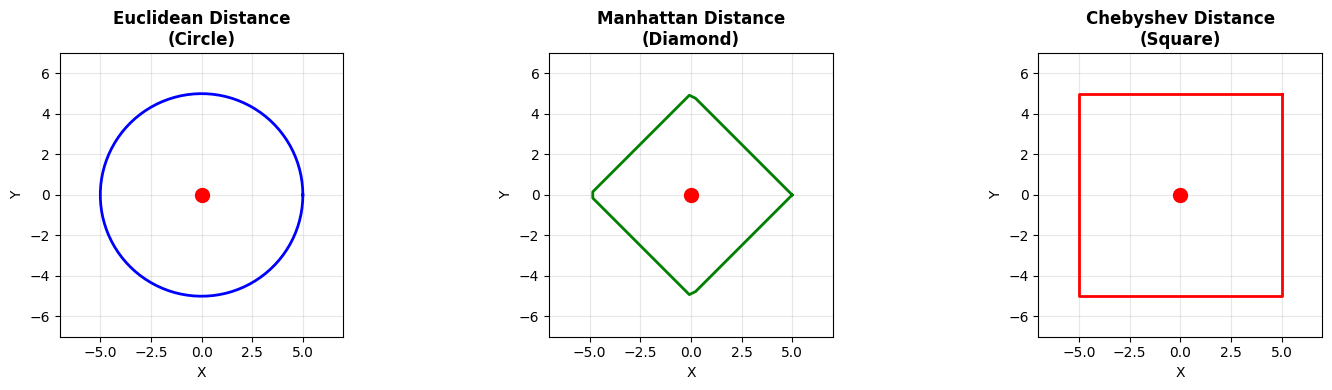

Points at distance=5 from origin form different shapes!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Reference point
origin = np.array([0, 0])

# Generate points at distance 5 from origin
theta = np.linspace(0, 2*np.pi, 100)

# Euclidean: circle
euclidean_points = 5 * np.array([np.cos(theta), np.sin(theta)])

# Manhattan: diamond
manhattan_x = 5 * np.cos(theta)
manhattan_y = 5 * np.sin(theta)
manhattan_dist = np.abs(manhattan_x) + np.abs(manhattan_y)
manhattan_x = manhattan_x * (5 / (manhattan_dist + 0.001))
manhattan_y = manhattan_y * (5 / (manhattan_dist + 0.001))

# Chebyshev: square
chebyshev_x = np.concatenate([
    np.linspace(5, -5, 25),
    np.full(25, -5),
    np.linspace(-5, 5, 25),
    np.full(25, 5)
])
chebyshev_y = np.concatenate([
    np.full(25, 5),
    np.linspace(5, -5, 25),
    np.full(25, -5),
    np.linspace(-5, 5, 25)
])

# Plot
axes[0].plot(euclidean_points[0], euclidean_points[1], 'b-', linewidth=2)
axes[0].plot(0, 0, 'ro', markersize=10)
axes[0].set_xlim(-7, 7)
axes[0].set_ylim(-7, 7)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Euclidean Distance\n(Circle)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

axes[1].plot(manhattan_x, manhattan_y, 'g-', linewidth=2)
axes[1].plot(0, 0, 'ro', markersize=10)
axes[1].set_xlim(-7, 7)
axes[1].set_ylim(-7, 7)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Manhattan Distance\n(Diamond)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

axes[2].plot(chebyshev_x, chebyshev_y, 'r-', linewidth=2)
axes[2].plot(0, 0, 'ro', markersize=10)
axes[2].set_xlim(-7, 7)
axes[2].set_ylim(-7, 7)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Chebyshev Distance\n(Square)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')

plt.tight_layout()
plt.show()

print("Points at distance=5 from origin form different shapes!")

---
## 4️⃣ Build KNN from Scratch

Let's implement KNN ourselves to understand it deeply.


---
## 7️⃣ Hyperparameter Tuning: Finding the Right K

The **K value** is crucial. Too small = overfitting. Too large = underfitting.

```
K=1: Trust only the closest neighbor
     ❌ Very noisy, overfits

K=3-5: Sweet spot for most problems
       ✅ Balances noise and learning

K=n_samples: Always predicts majority class
             ❌ Underfits completely
```


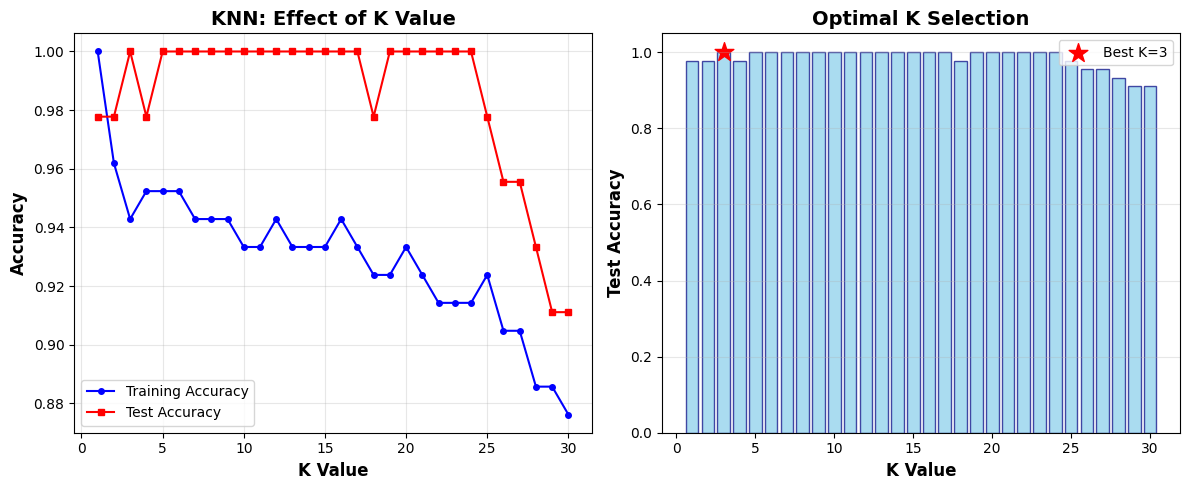


✅ Optimal K value: 3
✅ Best test accuracy: 1.0000


In [20]:
# Test different K values
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Track accuracies
k_values = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, 'b-o', label='Training Accuracy', markersize=4)
plt.plot(k_values, test_accuracies, 'r-s', label='Test Accuracy', markersize=4)
plt.xlabel('K Value', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('KNN: Effect of K Value', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Find best K
best_k = k_values[np.argmax(test_accuracies)]
best_acc = np.max(test_accuracies)

plt.subplot(1, 2, 2)
plt.bar(k_values, test_accuracies, color='skyblue', edgecolor='navy', alpha=0.7)
plt.scatter([best_k], [best_acc], color='red', s=200, marker='*', label=f'Best K={best_k}')
plt.xlabel('K Value', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Optimal K Selection', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Optimal K value: {best_k}")
print(f"✅ Best test accuracy: {best_acc:.4f}")

---
## 8️⃣ Real-World Example: Iris Classification

Let's build a complete pipeline from data loading to evaluation.


In [21]:
# 1. Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset Info:")
print(f"  Samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Classes: {len(target_names)}")
print(f"  Target names: {list(target_names)}")

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features (CRITICAL for KNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train with optimal K
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')
knn.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)

# 6. Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

# 8. Detailed report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Dataset Info:
  Samples: 150
  Features: 4
  Classes: 3
  Target names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

✅ Test Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



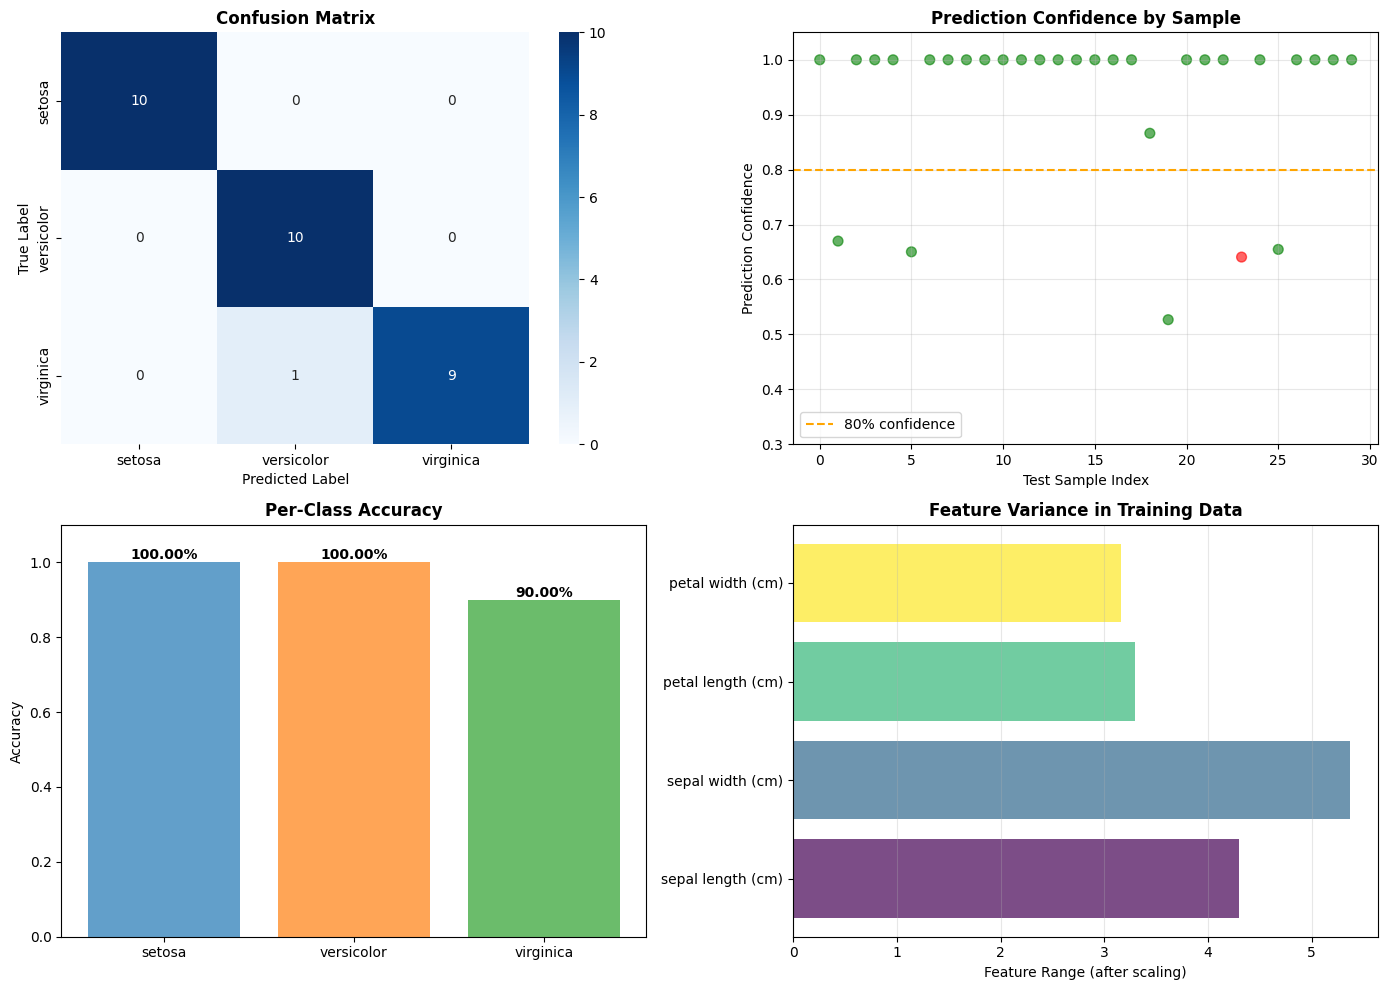

In [22]:
# Visualize predictions with confidence
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrix heatmap
ax = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=target_names, yticklabels=target_names)
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# Prediction confidence for each test sample
ax = axes[0, 1]
max_proba = np.max(y_pred_proba, axis=1)
colors = ['green' if y_pred[i] == y_test[i] else 'red' for i in range(len(y_test))]
ax.scatter(range(len(y_test)), max_proba, c=colors, alpha=0.6, s=50)
ax.axhline(y=0.8, color='orange', linestyle='--', label='80% confidence')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Prediction Confidence')
ax.set_title('Prediction Confidence by Sample', fontsize=12, fontweight='bold')
ax.set_ylim([0.3, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy by class
ax = axes[1, 0]
class_accuracies = []
for i in range(len(target_names)):
    mask = y_test == i
    if np.sum(mask) > 0:
        acc = np.mean(y_pred[mask] == y_test[mask])
        class_accuracies.append(acc)
    else:
        class_accuracies.append(0)

bars = ax.bar(target_names, class_accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1.1])
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

# Feature importance (distance-based)
ax = axes[1, 1]
# Measure how much each feature varies in the training set
feature_ranges = np.ptp(X_train_scaled, axis=0)  # peak-to-peak (max - min)
colors_feat = plt.cm.viridis(np.linspace(0, 1, len(feature_names)))
bars = ax.barh(feature_names, feature_ranges, color=colors_feat, alpha=0.7)
ax.set_xlabel('Feature Range (after scaling)')
ax.set_title('Feature Variance in Training Data', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## 9️⃣ Pros & Cons of KNN

### ✅ Advantages

| Pro | Explanation |
|-----|-------------|
| **Simple** | Easy to understand and implement |
| **No training** | Lazy learner - just memorize data |
| **Non-parametric** | No assumptions about data distribution |
| **Works for both** | Classification and regression |
| **Multi-class** | Naturally handles multiple classes |
| **Effective** | Often performs surprisingly well |

### ❌ Disadvantages

| Con | Explanation |
|-----|-------------|
| **Slow prediction** | Must calculate distance to all points |
| **Memory intensive** | Stores entire training set |
| **Feature scaling** | Sensitive to unscaled features |
| **Curse of dimensionality** | Struggles with many features |
| **Imbalanced data** | Majority class can dominate |
| **Outliers** | Sensitive to noise |

### 🎯 When to use KNN

✅ **Good for:**
- Small to medium datasets (< 100k samples)
- Low to medium dimensions (< 20 features)
- When you need quick baseline
- Non-linear classification problems
- When speed doesn't matter

❌ **Avoid for:**
- Large datasets (millions of samples)
- High-dimensional data (images, text)
- Real-time predictions
- When memory is limited
- Highly imbalanced classes


---
## 🔟 Tips & Tricks for KNN

### 1. Always Scale Features


---
## 📌 Summary: KNN Masterclass

### Key Takeaways:

1. **Intuition**: Look at K nearest points and vote
2. **Distance Metrics**: Euclidean, Manhattan, Chebyshev
3. **Kernels**: Transform similarity instead of distance
4. **Hyperparameter K**: Find optimal value via validation
5. **Scaling**: ALWAYS scale features before KNN
6. **Weights**: Use distance weighting for better results
7. **Trade-offs**: Simple but slow on large data

### Decision Tree:

```
Do you have < 100k samples?
├─ YES → Try KNN
│       ├─ Scale features ✅
│       ├─ Find optimal K (3-7 usually)
│       ├─ Use distance weighting
│       └─ Done!
└─ NO → Use approximation or different algorithm
```

### Quick KNN Template:

```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Prepare data
X_train, X_test, y_train, y_test = train_test_split(X, y)

# 2. Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Train
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)

# 4. Evaluate
score = knn.score(X_test, y_test)
```

## 🎓 Next Steps:

Try KNN on:
- Other datasets (Titanic, MNIST, etc.)
- Regression (use `KNeighborsRegressor`)
- Different distance metrics
- Kernelized versions

Happy learning! 🚀
